In [1]:
batch_size = 3
batches_count = 3
# endpoint = "http://localhost:3000/generate_anime"
endpoint = "http://192.69.210.82:10006/generate"
# endpoint = "http://192.69.210.82:80/generate_anime"

In [2]:
from model import GenerateRequest, PipelineParams

file_mode = True

def generate_request(prompt: str, seed: int) -> GenerateRequest:
    return GenerateRequest(
        prompt=prompt,
        seed=seed,
        pipeline_params=PipelineParams(
            num_inference_steps=25,
            width=1024,
            height=1024,
            guidance_scale=7.0,
            negative_prompt="out of frame, nude, duplicate, watermark, signature, mutated, text, blurry, worst quality, low quality, artificial, texture artifacts, jpeg artifacts"
        ),
        timeout=12
    )
    
def generate_from_file():
    prompts = []
    with open('./test_prompts.txt', 'r') as file:
        prompts = [line.strip() for line in file if line.strip()]
        
    seeds = [42, 228, 322]
    
    results = []
    
    for seed in seeds:
        for prompt in prompts:
            results.append(generate_request(prompt, seed))
            
    return results

def generate_random():
    return [generate_request(f"a beautiful image, seed: {i}", i) for i in range(batch_size * batches_count)]

requests = generate_from_file() if file_mode else generate_random()

/root/.pyenv/versions/3.10.14/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/.pyenv/versions/3.10.14/lib/python3.10/site-packages/transformers/utils/generic.py:311: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/root/.pyenv/versions/3.10.14/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/root/.pyenv/versions/3.10.14/lib/python3.10/site-packages/transformers/utils/generic.py:311: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.regis

In [3]:
import asyncio
import base64
from dataclasses import dataclass
from typing import Optional
import time
from anyio import sleep
import httpx
import io
from PIL import Image

@dataclass
class OperationResult:
    prompt: str
    elapsed_time: float
    is_success: bool
    image: Optional[Image.Image]

async def send_request(request: GenerateRequest) -> OperationResult:
    time_start = time.time()
    async with httpx.AsyncClient(timeout=100) as client:
        response = await client.post(endpoint, json=request.model_dump())
    elapsed_time = time.time() - time_start
    
    print(f"Request took {elapsed_time} seconds and returned status code {response.status_code}")
    
    if response.status_code != 200:
        print(response.json())
        return OperationResult(prompt=request.prompt, elapsed_time=elapsed_time, is_success=False, image=None)
    else:
        base64_image = response.json()["image"]
        image = Image.open(io.BytesIO(base64.b64decode(base64_image)))
        
        return OperationResult(prompt=request.prompt, elapsed_time=elapsed_time, is_success=True, image=image)

async def send_batch(requests: list[GenerateRequest]) -> list[OperationResult]:
    tasks = [send_request(request) for request in requests]
    results = await asyncio.gather(*tasks)
    
    # Sort results according to the order of requests
    sorted_results = sorted(results, key=lambda x: requests.index(next(req for req in requests if req.prompt == x.prompt)))
    return sorted_results

async def benchmark():
    time_start = time.time()
    batches = [requests[i:i+batch_size] for i in range(0, len(requests), batch_size)]
    results = []
    
    for batch in batches:
        results.extend(await send_batch(batch))
        
    return { "results": results, "elapsed_time": time.time() - time_start }

results = await benchmark()

Request took 3.4544858932495117 seconds and returned status code 200
Request took 7.4954822063446045 seconds and returned status code 200
Request took 11.538805961608887 seconds and returned status code 200
Request took 3.527435541152954 seconds and returned status code 200
Request took 7.47495698928833 seconds and returned status code 200
Request took 11.518454551696777 seconds and returned status code 200
Request took 3.528247117996216 seconds and returned status code 200
Request took 7.476257801055908 seconds and returned status code 200
Request took 11.519800901412964 seconds and returned status code 200
Request took 3.493943929672241 seconds and returned status code 200
Request took 7.555189371109009 seconds and returned status code 200
Request took 11.502313137054443 seconds and returned status code 200
Request took 3.5395443439483643 seconds and returned status code 200
Request took 7.482523202896118 seconds and returned status code 200
Request took 11.527395248413086 seconds an

In [4]:
def generate_report(results: list[OperationResult], elapsed_time: float):
    print(f"{len(results)} requests were sent")
    print(f"{len([r for r in results if r.is_success])} requests were successful")
    print(f"{len([r for r in results if not r.is_success])} requests failed")
    
    average_time = sum([r.elapsed_time for r in results if r.is_success]) / len([r for r in results if r.is_success])
    print(f"Average response time: {average_time} seconds")
    
    requests_per_second = len([r for r in results if r.is_success]) / elapsed_time
    print(f"Requests per second: {requests_per_second}")
    print(f"Total Volume: {int(requests_per_second * 600)}")

generate_report(results["results"], results["elapsed_time"])

1743 requests were sent
1743 requests were successful
0 requests failed
Average response time: 7.520907075119237 seconds
Requests per second: 0.22094193087058403
Total Volume: 132


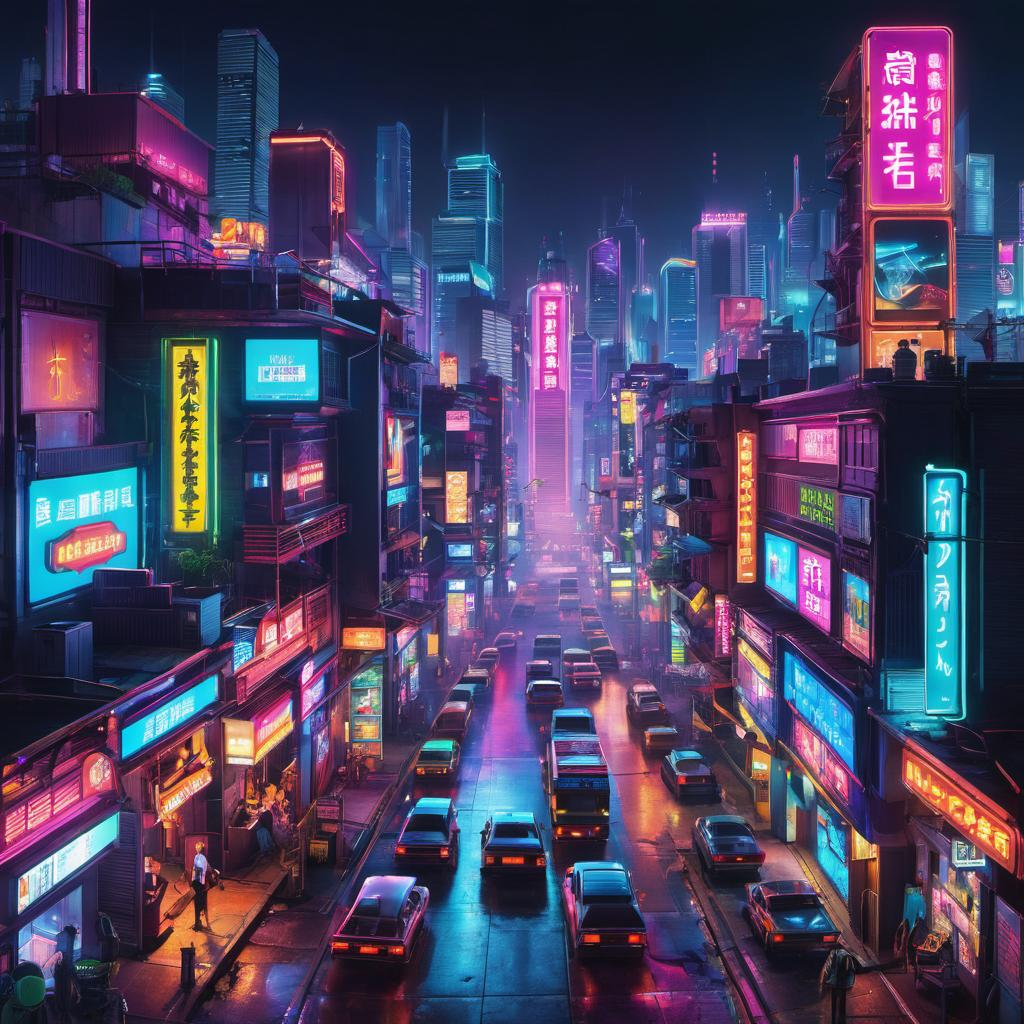

In [5]:
results["results"][1].image

In [6]:
import os

# Create the 'tests' folder if it doesn't exist
os.makedirs('tests', exist_ok=True)

# Save images to the 'tests' folder
for index, result in enumerate(results["results"], start=1):
    if result.is_success and result.image:
        image_path = os.path.join('tests', f'{index}_original.jpg')
        result.image.save(image_path)
        print(f"Saved image: {image_path}")
    elif not result.is_success:
        print(f"Failed to save image for index {index}: Request was not successful")
    else:
        print(f"Failed to save image for index {index}: No image data available")


Saved image: tests/1_original.jpg
Saved image: tests/2_original.jpg
Saved image: tests/3_original.jpg
Saved image: tests/4_original.jpg
Saved image: tests/5_original.jpg
Saved image: tests/6_original.jpg
Saved image: tests/7_original.jpg
Saved image: tests/8_original.jpg
Saved image: tests/9_original.jpg
Saved image: tests/10_original.jpg
Saved image: tests/11_original.jpg
Saved image: tests/12_original.jpg
Saved image: tests/13_original.jpg
Saved image: tests/14_original.jpg
Saved image: tests/15_original.jpg
Saved image: tests/16_original.jpg
Saved image: tests/17_original.jpg
Saved image: tests/18_original.jpg
Saved image: tests/19_original.jpg
Saved image: tests/20_original.jpg
Saved image: tests/21_original.jpg
Saved image: tests/22_original.jpg
Saved image: tests/23_original.jpg
Saved image: tests/24_original.jpg
Saved image: tests/25_original.jpg
Saved image: tests/26_original.jpg
Saved image: tests/27_original.jpg
Saved image: tests/28_original.jpg
Saved image: tests/29_origina